In [1]:
import os
import numpy as np
import scipy.io as sio
from scipy.signal import hilbert, resample
from scipy.fft import rfft

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    average_precision_score,
)

from sklearn.manifold import TSNE
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# ---------------- Config & constants ----------------
CONFIG = {
    'root_dir': './UOS_Transfer',
    'bearing_name': 'bearing2',
    'all_speeds': [600, 800, 1000, 1200, 1400, 1600],
    'batch_size': 32,
    'epochs': 50,
    'fs': 16000,
    'fs_folder': 'SamplingRate_16000',
}

BEARING_MAP = {'B': 0, 'IR': 1, 'OR': 2}
MECH_MAP    = {'U': 3, 'M': 4, 'L': 5}
TARGET_NAMES = ['Ball', 'Inner', 'Outer', 'Unbalance', 'Misalign', 'Looseness']

## Summary

This notebook implements a dual-branch attention fusion model for multi-label fault diagnosis in bearings using vibration signals. The key components include:

### Data Preprocessing
- **Angular Resampling**: Converts raw vibration signals to angular domain based on rotational speed.
- **Feature Extraction**: Computes envelope spectrum and FFT features from signal segments.
- **Data Splitting**: Splits each file into 70% training and 30% testing portions based on time, ensuring temporal order.

### Model Architecture
- **Single-Branch Models**: Baseline models using either envelope or FFT features.
- **Dual-Branch Model**: Fuses envelope and FFT features using cross-attention mechanism with CBAM (Convolutional Block Attention Module) for spatial attention.

### Training and Evaluation
- Trains models on clean data and evaluates performance on multi-label classification (Ball, Inner Race, Outer Race, Unbalance, Misalignment, Looseness).
- Includes noise robustness testing by training with various SNR levels and testing on noisy data.
- Performs threshold calibration to optimize classification thresholds for each fault type based on F1-score.

### Key Features
- Handles multi-label classification with BCEWithLogitsLoss.
- Uses PyTorch for model implementation and training.
- Includes visualization for noise robustness and threshold calibration.
- Supports ablation studies to compare model variants.

The dual-branch approach with attention fusion demonstrates improved performance over single-branch baselines, especially under noisy conditions.

## Preprocessor

In [3]:
def add_awgn(signal, snr_db):
    """Add Gaussian noise SNR (dB)."""
    P_signal = np.mean(signal ** 2)
    P_noise  = P_signal / (10 ** (snr_db / 10.0))
    return signal + np.random.normal(0, np.sqrt(P_noise), len(signal))


def parse_label(f_name):
    """Parse filename -> one-hot label (6 dimensions)."""
    parts = f_name.split('_')
    mech_raw, bear_raw = parts[0], parts[1]
    mech_key = 'H' if mech_raw == 'H' else ('L' if mech_raw == 'L' else mech_raw[0])
    label_vec = np.zeros(6, dtype=np.float32)
    if bear_raw in BEARING_MAP: label_vec[BEARING_MAP[bear_raw]] = 1.0
    if mech_key in MECH_MAP:    label_vec[MECH_MAP[mech_key]]    = 1.0
    return label_vec


class UOSPreProcessor:
    """Preprocessing: Angular resampling + Envelope & FFT features."""

    def __init__(self, root_dir, bearing_type,
                 target_spr=400, segment_len_rev=10, output_len=2048):
        self.root_dir = root_dir
        self.bearing_type = bearing_type
        self.target_spr = target_spr
        self.window_size = int(target_spr * segment_len_rev)  # 4000
        self.output_len = output_len  # 2048

    def angular_resampling(self, signal, fs, rpm):
        duration = len(signal) / fs
        new_length = int((rpm / 60.0) * duration * self.target_spr)
        return resample(signal, new_length) if new_length > 0 else np.zeros(self.window_size)

    def _spec_to_feat(self, spec):
        if len(spec) >= self.output_len:
            s = spec[:self.output_len]
        else:
            s = np.pad(spec, (0, self.output_len - len(spec)))
        s = 20 * np.log10(s + 1e-6)
        s = (s - np.median(s)) / 20.0
        return np.clip(s, -5, 5).astype(np.float32)

    def extract_features(self, segment):
        analytic = hilbert(segment)
        envelope = np.abs(analytic) - np.mean(np.abs(analytic))
        env_spec = np.abs(rfft(envelope, n=self.window_size)) / len(envelope)
        fft_spec = np.abs(rfft(segment, n=self.window_size)) / len(segment)
        env_feat = self._spec_to_feat(env_spec)
        fft_feat = self._spec_to_feat(fft_spec)
        return env_feat, fft_feat

    def _iter_segments(self, speeds_list, fs_folder,
                       max_segs=None, train_ratio=0.7):
        """
        With each file .mat:
        - Resample -> sig
        - Split sig: first 70% (train), last 30% (test) according to time
        - Cut overlapping segments in each part and yield with tag 'train' / 'test'
        """
        base_path = os.path.join(self.root_dir, self.bearing_type, fs_folder)
        for speed in speeds_list:
            speed_path = os.path.join(base_path, f"RotatingSpeed_{speed}")
            if not os.path.exists(speed_path):
                continue

            # Sort file names so that the file order reflects time (if file names have time meaning)
            files = sorted([f for f in os.listdir(speed_path) if f.endswith('.mat')])

            for f_name in files:
                try:
                    label_vec = parse_label(f_name)
                    mat = sio.loadmat(os.path.join(speed_path, f_name))
                    raw = mat.get('Data', mat.get('data')).flatten()

                    sig = self.angular_resampling(raw, CONFIG['fs'], speed)

                    # Split according to time: first 70% – last 30%
                    split_idx = int(len(sig) * train_ratio)
                    sig_train = sig[:split_idx]
                    sig_test = sig[split_idx:]

                    step = self.window_size // 2

                    # --- train part ---
                    n_tr = (len(sig_train) - self.window_size) // step
                    if max_segs is not None:
                        n_tr = min(n_tr, max_segs)
                    for i in range(max(n_tr, 0)):
                        seg = sig_train[i*step : i*step + self.window_size]
                        yield seg, label_vec, "train"

                    # --- test part ---
                    n_te = (len(sig_test) - self.window_size) // step
                    if max_segs is not None:
                        n_te = min(n_te, max_segs)
                    for i in range(max(n_te, 0)):
                        seg = sig_test[i*step : i*step + self.window_size]
                        yield seg, label_vec, "test"
                except:
                    pass

    def load_data(self, speeds_list,
                  snr=None, snr_values=None,
                  fs_folder='SamplingRate_16000', max_segs=None,
                  train_ratio=0.7):
        """
        Return (train_data, test_data) split according to 70%-30% time in EACH FILE.
        """
        data_tr = {'env': [], 'fft': [], 'label': []}
        data_te = {'env': [], 'fft': [], 'label': []}

        for seg, label_vec, split in self._iter_segments(
                speeds_list, fs_folder, max_segs, train_ratio):

            if snr_values is not None:
                seg = add_awgn(seg, float(np.random.choice(snr_values)))
            elif snr is not None:
                seg = add_awgn(seg, snr)

            e, f = self.extract_features(seg)

            if split == "train":
                data_tr['env'].append(e)
                data_tr['fft'].append(f)
                data_tr['label'].append(label_vec)
            else:
                data_te['env'].append(e)
                data_te['fft'].append(f)
                data_te['label'].append(label_vec)

        data_tr = {k: np.array(v) for k, v in data_tr.items()}
        data_te = {k: np.array(v) for k, v in data_te.items()}
        return data_tr, data_te

    def process_all_speeds(self, speeds_list, fs_folder='SamplingRate_16000',
                           train_ratio=0.7):
        print(f"--- Processing {self.bearing_type} (Speeds: {speeds_list}) ---")
        return self.load_data(speeds_list,
                              fs_folder=fs_folder,
                              max_segs=50,
                              train_ratio=train_ratio)

## Dataset

In [4]:
class MultiLabelDataset(Dataset):
    def __init__(self, env, fft, labels):
        self.env    = torch.tensor(env, dtype=torch.float32).unsqueeze(1)
        self.fft    = torch.tensor(fft, dtype=torch.float32).unsqueeze(1)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.env[idx], self.fft[idx], self.labels[idx]


def make_loaders(data, batch_size, test_size=0.2):
    labels     = data['label']
    str_labels = ["".join(x.astype(int).astype(str)) for x in labels]
    X_env_tr, X_env_te, X_fft_tr, X_fft_te, y_tr, y_te = train_test_split(
        data['env'], data['fft'], labels,
        test_size=test_size, random_state=42, stratify=str_labels
    )
    train_dl = DataLoader(MultiLabelDataset(X_env_tr, X_fft_tr, y_tr), batch_size=batch_size, shuffle=True)
    test_dl  = DataLoader(MultiLabelDataset(X_env_te, X_fft_te, y_te), batch_size=batch_size, shuffle=False)
    return train_dl, test_dl


## Model Architecture

In [5]:
class CBAM1D(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.sig_ch = nn.Sigmoid()
        self.conv_sp = nn.Conv1d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sig_sp  = nn.Sigmoid()

    def forward(self, x):
        b, c, _ = x.size()
        avg = self.fc(self.avg_pool(x).view(b, c)).view(b, c, 1)
        mx  = self.fc(self.max_pool(x).view(b, c)).view(b, c, 1)
        x   = x * self.sig_ch(avg + mx)
        sp  = torch.cat([x.mean(1, keepdim=True), x.max(1, keepdim=True)[0]], dim=1)
        return x * self.sig_sp(self.conv_sp(sp))


class DeepBackbone(nn.Module):
    def __init__(self, k_first=64, s_first=4):
        super().__init__()

        def block(ci, co, k, s, p, pool=True):
            layers = [nn.Conv1d(ci, co, k, s, p), nn.BatchNorm1d(co), nn.ReLU()]
            if pool:
                layers.append(nn.MaxPool1d(2))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            block(1,   16,  k_first, s_first, k_first//2),
            block(16,  32,  3, 1, 1),
            block(32,  64,  3, 1, 1),
            block(64,  128, 3, 1, 1),
            block(128, 256, 3, 1, 1, pool=False),
        )
        self.cbam = CBAM1D(256)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        return self.pool(x).squeeze(-1)  # (B, 256)


class AttentionClassifierHead(nn.Module):
    """SE-style attention head that weighs feature channels before classification."""
    def __init__(self, input_dim, num_classes, reduction=4):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(input_dim, input_dim // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(input_dim // reduction, input_dim, bias=False),
            nn.Sigmoid(),
        )
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        # x shape: (B, D)
        attn_weights = self.attention(x)  # (B, D)
        x_weighted = x * attn_weights
        return self.classifier(x_weighted)


class AttentionFusionModel(nn.Module):
    """Dual-Branch: Env + FFT with SE-style attention fusion."""
    def __init__(self, num_classes=6, d_model=256):
        super().__init__()
        self.env_branch = DeepBackbone()
        self.fft_branch = DeepBackbone(k_first=16, s_first=2)
        self.head = AttentionClassifierHead(d_model * 2, num_classes)

    def forward(self, env, fft):
        fe = self.env_branch(env)  # (B, 256)
        ff = self.fft_branch(fft)  # (B, 256)
        fused = torch.cat([fe, ff], dim=1)  # (B, 512)
        return self.head(fused)


class SingleBranchModel(nn.Module):
    """Baseline: only use 1 branch (env or fft)."""
    def __init__(self, mode='fft', num_classes=6):
        super().__init__()
        assert mode in ('env', 'fft')
        self.mode     = mode
        self.backbone = DeepBackbone() if mode == 'env' else DeepBackbone(k_first=16, s_first=2)
        self.head     = AttentionClassifierHead(256, num_classes)

    def forward(self, env, fft):
        x = env if self.mode == 'env' else fft
        feat = self.backbone(x)
        return self.head(feat)

## Train & Evaluate Utilities

In [6]:
def train_model_with_val(model, train_dl, val_dl, epochs, device, lr=0.001):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    # Dictionary lưu lại lịch sử loss để vẽ biểu đồ
    history = {'train_loss': [], 'val_loss': []}

    for ep in range(epochs):
        # --- PHÁT HUẤN LUYỆN (TRAINING) ---
        model.train()
        train_loss = 0.0
        for env, fft, lbl in train_dl:
            env, fft, lbl = env.to(device), fft.to(device), lbl.to(device)
            optimizer.zero_grad()
            logits = model(env, fft)
            loss   = criterion(logits, lbl)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        train_loss_avg = train_loss / len(train_dl)
        history['train_loss'].append(train_loss_avg)
        
        # --- PHA ĐÁNH GIÁ (VALIDATION) ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for env, fft, lbl in val_dl:
                env, fft, lbl = env.to(device), fft.to(device), lbl.to(device)
                logits = model(env, fft)
                loss   = criterion(logits, lbl)
                val_loss += loss.item()
                
        val_loss_avg = val_loss / len(val_dl)
        history['val_loss'].append(val_loss_avg)

        # In tiến độ
        if (ep + 1) % 5 == 0 or ep == 0:
            print(f"Epoch {ep+1}/{epochs} | Train Loss: {train_loss_avg:.4f} | Val Loss: {val_loss_avg:.4f}")
            
    return model, history

def decode_label(row, target_names):
    active_idx = np.where(row == 1)[0]
    if len(active_idx) == 0: 
        return "Normal"
    return " + ".join([target_names[i] for i in active_idx])


def evaluate_model(model, loader, device, threshold=0.5):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for env, fft, lbl in loader:
            env, fft = env.to(device), fft.to(device)
            logits = model(env, fft)
            probs  = torch.sigmoid(logits)
            y_prob.extend(probs.cpu().numpy())
            y_pred.extend((probs > threshold).float().cpu().numpy())
            y_true.extend(lbl.numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_prob)


## Training

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = UOSPreProcessor(CONFIG['root_dir'], CONFIG['bearing_name'])

# 1) Create clean data: already have train/test 70%-30% according to time in each file
train_data, test_data = processor.process_all_speeds(
    CONFIG['all_speeds'],
    fs_folder=CONFIG['fs_folder'],
    train_ratio=0.7
)

train_loader = DataLoader(
    MultiLabelDataset(train_data['env'], train_data['fft'], train_data['label']),
    batch_size=CONFIG['batch_size'],
    shuffle=True   # shuffle within train (by batch) does not break "time split" anymore
)
test_loader = DataLoader(
    MultiLabelDataset(test_data['env'], test_data['fft'], test_data['label']),
    batch_size=CONFIG['batch_size'],
    shuffle=False
)

# 2) Train as usual
models = {
    "Envelope-Only": SingleBranchModel(mode="env"),
    "FFT-Only": SingleBranchModel(mode="fft"),
    "Dual-Branch (Ours)": AttentionFusionModel(),
}

trained_models = {}

print("\n" + "="*60)
print(" START TRAINING (CLEAN DATA)")
print("="*60)

for name, model in models.items():
    print(f"\n>>> Training model: {name}")
    model, history = train_model_with_val(model, train_loader, test_loader, CONFIG['epochs'], device)
    y_true, y_pred, y_prob = evaluate_model(model, test_loader, device)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    print(f" Accuracy: {acc*100:.2f}%")
    print(f" Macro P/R/F1: {prec:.3f} / {rec:.3f} / {f1:.3f}")
    trained_models[name] = model

    # --- CHỈ LƯU LẠI KẾT QUẢ CỦA MẠNG DUAL-BRANCH ---
    if name == "Dual-Branch (Ours)":
        # Chuyển đổi vector số thành chuỗi tên lỗi (để sau này vẽ Confusion Matrix)
        y_true_str = [decode_label(row, TARGET_NAMES) for row in y_true]
        y_pred_str = [decode_label(row, TARGET_NAMES) for row in y_pred]
        
        # ĐẶT TÊN FILE (NHỚ ĐỔI TÊN NÀY KHI CHẠY CHO VÒNG BI KHÁC, VD: results_N204.npz)
        save_filename = "results_6204.npz" 
        
        np.savez(save_filename, 
                 train_loss=history['train_loss'], 
                 val_loss=history['val_loss'], 
                 y_true=y_true_str, 
                 y_pred=y_pred_str)
        print(f" [+] Đã lưu thành công Loss và Prediction của Dual-Branch vào: {save_filename}")

--- Processing bearing2 (Speeds: [600, 800, 1000, 1200, 1400, 1600]) ---

 START TRAINING (CLEAN DATA)

>>> Training model: Envelope-Only
Epoch 1/50 | Train Loss: 0.3292 | Val Loss: 0.2878
Epoch 5/50 | Train Loss: 0.0847 | Val Loss: 0.3225
Epoch 10/50 | Train Loss: 0.0345 | Val Loss: 0.2380
Epoch 15/50 | Train Loss: 0.0231 | Val Loss: 0.1042
Epoch 20/50 | Train Loss: 0.0200 | Val Loss: 0.2024
Epoch 25/50 | Train Loss: 0.0163 | Val Loss: 0.1232
Epoch 30/50 | Train Loss: 0.0157 | Val Loss: 0.2233
Epoch 35/50 | Train Loss: 0.0099 | Val Loss: 0.2528
Epoch 40/50 | Train Loss: 0.0123 | Val Loss: 0.1052
Epoch 45/50 | Train Loss: 0.0077 | Val Loss: 0.1870
Epoch 50/50 | Train Loss: 0.0101 | Val Loss: 0.0727
 Accuracy: 90.76%
 Macro P/R/F1: 0.969 / 0.960 / 0.964

>>> Training model: FFT-Only
Epoch 1/50 | Train Loss: 0.2548 | Val Loss: 0.1558
Epoch 5/50 | Train Loss: 0.0267 | Val Loss: 0.0359
Epoch 10/50 | Train Loss: 0.0148 | Val Loss: 0.0371
Epoch 15/50 | Train Loss: 0.0060 | Val Loss: 0.0343
E

## Test Noise


Training (noise-robust): Envelope-Only
Epoch 1/50 | Loss: 0.3992
Epoch 5/50 | Loss: 0.2316
Epoch 10/50 | Loss: 0.1682
Epoch 15/50 | Loss: 0.1238
Epoch 20/50 | Loss: 0.0912
Epoch 25/50 | Loss: 0.0661
Epoch 30/50 | Loss: 0.0519
Epoch 35/50 | Loss: 0.0485
Epoch 40/50 | Loss: 0.0415
Epoch 45/50 | Loss: 0.0351
Epoch 50/50 | Loss: 0.0326

-> Test SNR = 10 dB
 Macro F1 = 0.9054

-> Test SNR = 5 dB
 Macro F1 = 0.8590

-> Test SNR = 0 dB
 Macro F1 = 0.7748

-> Test SNR = -4 dB
 Macro F1 = 0.6778

-> Test SNR = -8 dB
 Macro F1 = 0.5341

Training (noise-robust): FFT-Only
Epoch 1/50 | Loss: 0.3518
Epoch 5/50 | Loss: 0.1098
Epoch 10/50 | Loss: 0.0594
Epoch 15/50 | Loss: 0.0352
Epoch 20/50 | Loss: 0.0245
Epoch 25/50 | Loss: 0.0227
Epoch 30/50 | Loss: 0.0195
Epoch 35/50 | Loss: 0.0152
Epoch 40/50 | Loss: 0.0133
Epoch 45/50 | Loss: 0.0144
Epoch 50/50 | Loss: 0.0116

-> Test SNR = 10 dB
 Macro F1 = 0.9484

-> Test SNR = 5 dB
 Macro F1 = 0.9357

-> Test SNR = 0 dB
 Macro F1 = 0.9088

-> Test SNR = -4 d

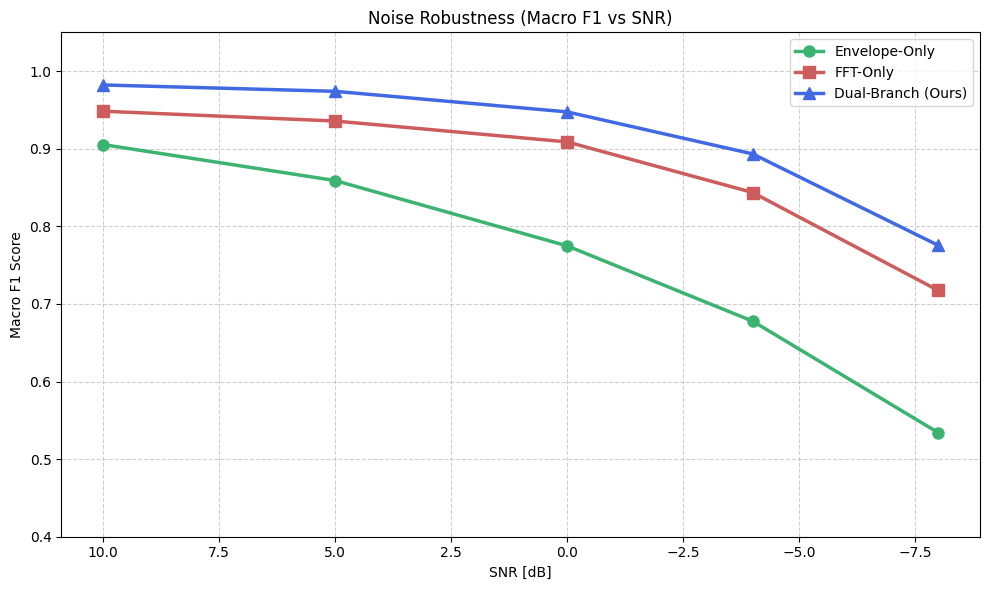

In [8]:
def run_noise_robustness(model_constructors, config,
                         train_snr_values=None, test_snr_list=None, epochs=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    processor = UOSPreProcessor(config['root_dir'], config['bearing_name'])
    test_snr_list = test_snr_list or [10, 5, 0, -4, -8]
    results = {name: [] for name in model_constructors}

    # === Train data with random noise (if any), use the first 70% time part in the file ===
    train_data, _ = processor.load_data(
        config['all_speeds'],
        snr_values=train_snr_values,
        fs_folder=config['fs_folder'],
        max_segs=100,
        train_ratio=0.7
    )

    train_dl = DataLoader(
        MultiLabelDataset(train_data['env'], train_data['fft'], train_data['label']),
        batch_size=config['batch_size'],
        shuffle=True
    )

    for name, constructor in model_constructors.items():
        print(f"\n{'='*50}\nTraining (noise-robust): {name}\n{'='*50}")
        model = train_model(constructor(), train_dl, epochs, device)

        for snr in test_snr_list:
            print(f"\n-> Test SNR = {snr} dB")

            # === Test data: use the last 30% time part in the file, add noise according to snr ===
            _, test_data = processor.load_data(
                config['all_speeds'],
                snr=snr,
                fs_folder=config['fs_folder'],
                max_segs=20,
                train_ratio=0.7
            )

            test_dl = DataLoader(
                MultiLabelDataset(test_data['env'], test_data['fft'], test_data['label']),
                batch_size=config['batch_size'],
                shuffle=False
            )

            y_true, y_pred, _ = evaluate_model(model, test_dl, device)
            _, _, f1_macro, _ = precision_recall_fscore_support(
                y_true, y_pred, average='macro', zero_division=0
            )
            results[name].append(f1_macro)
            print(f" Macro F1 = {f1_macro:.4f}")

        del model
        torch.cuda.empty_cache()

    # Plot remains the same as your old code
    plt.figure(figsize=(10, 6))
    markers = ['o', 's', '^']
    colors = ['mediumseagreen', 'indianred', 'royalblue']
    for (name, scores), m, c in zip(results.items(), markers, colors):
        plt.plot(test_snr_list, scores, marker=m, lw=2.5, ms=8, label=name, color=c)
    plt.gca().invert_xaxis()
    plt.title('Noise Robustness (Macro F1 vs SNR)')
    plt.xlabel('SNR [dB]')
    plt.ylabel('Macro F1 Score')
    plt.ylim(0.4, 1.05)
    plt.grid(True, ls='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results


# Enable/disable noise robustness experiment
RUN_NOISE_EXPERIMENT = True

if RUN_NOISE_EXPERIMENT:
    model_ctors = {
        "Envelope-Only":      lambda: SingleBranchModel(mode="env"),
        "FFT-Only":           lambda: SingleBranchModel(mode="fft"),
        "Dual-Branch (Ours)": lambda: AttentionFusionModel(),
    }
    noise_results = run_noise_robustness(
        model_ctors,
        CONFIG,
        train_snr_values=[20, 15, 10, 5, 0, -4, -8],
        test_snr_list=[10, 5, 0, -4, -8],
        epochs=50,
    )

## Ablation Study

In [9]:
# def run_ablation(config):
#     device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     processor = UOSPreProcessor(config['root_dir'], config['bearing_name'])
#     data      = processor.process_all_speeds(config['all_speeds'])
#     train_dl, test_dl = make_loaders(data, config['batch_size'])

#     models = {
#         'Envelope-Only':    SingleBranchModel(mode='env'),
#         'FFT-Only':         SingleBranchModel(mode='fft'),
#         'Dual-Branch (Ours)': AttentionFusionModel(),
#     }

#     print("\n" + "="*60)
#     print("  ABLATION STUDY")
#     print("="*60)
#     for name, model in models.items():
#         print(f"\n>>> Training: {name}...")
#         train_model(model, train_dl, config['epochs'], device)
#         y_true, y_pred, _ = evaluate_model(model, test_dl, device)
#         acc = accuracy_score(y_true, y_pred)
#         print(f"Completed {name}. Global Accuracy: {acc*100:.2f}%")

# run_ablation(CONFIG)

## Threshold Calibration

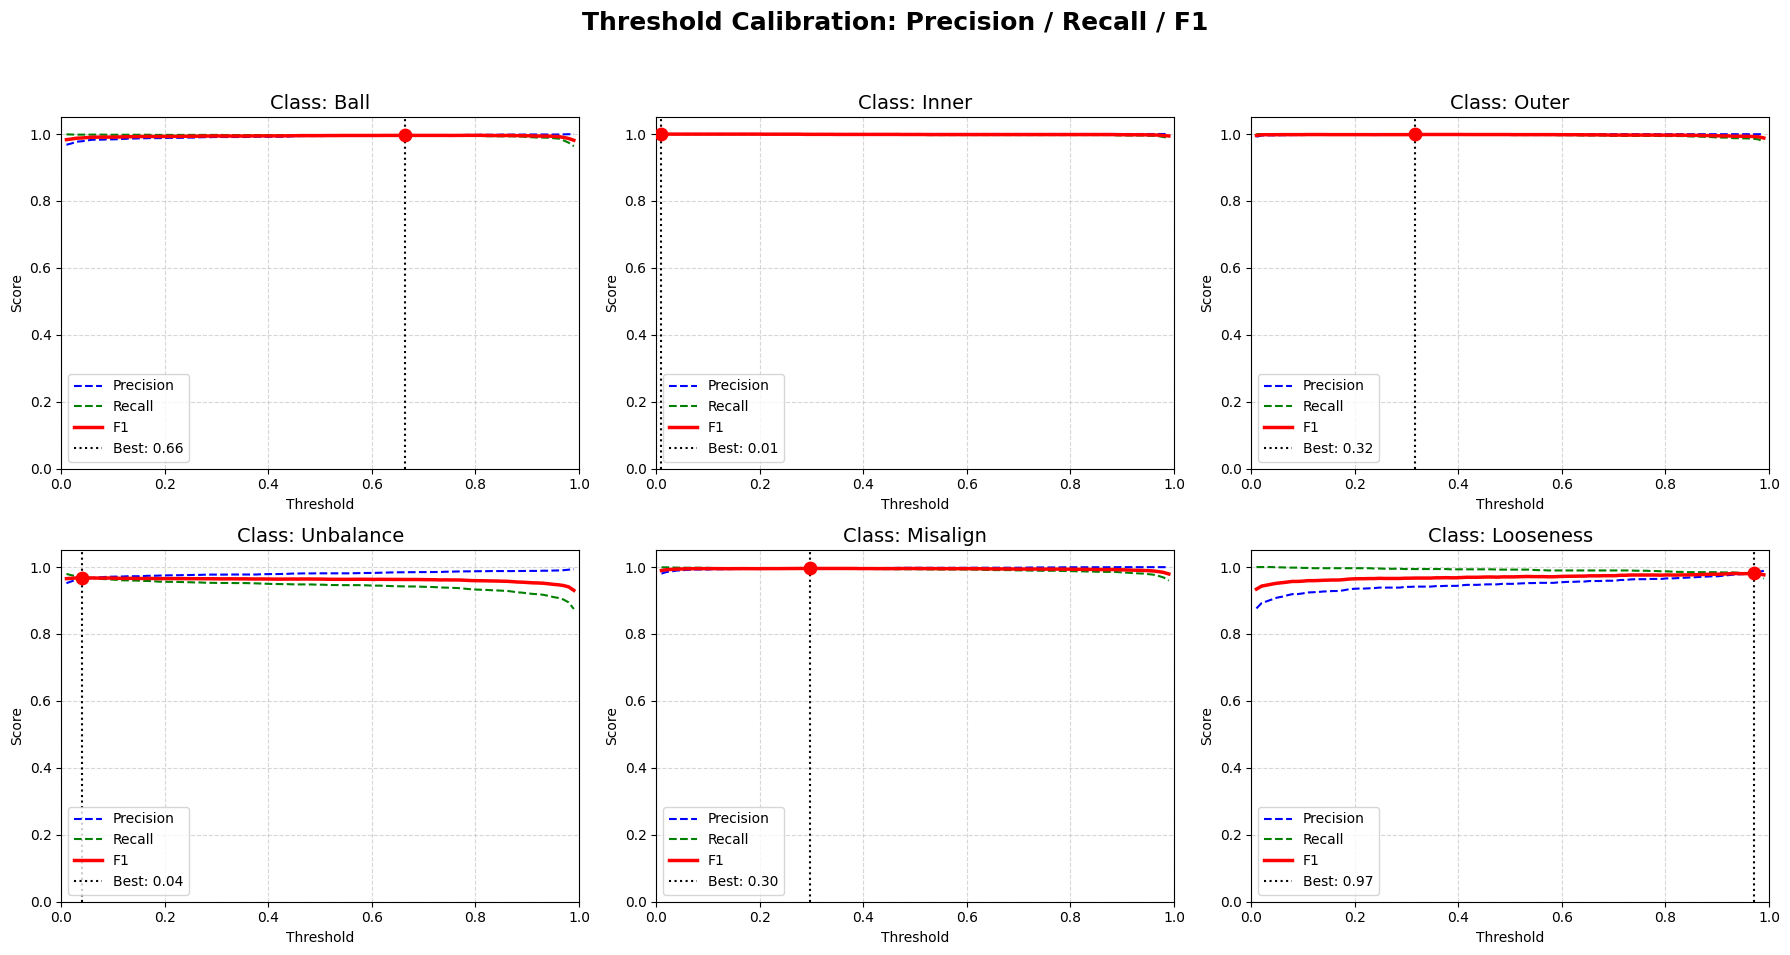


 OPTIMAL CLASSIFICATION THRESHOLDS (BASED ON MAX F1-SCORE) 
Fault: Ball         -> Optimal Threshold: 0.66
Fault: Inner        -> Optimal Threshold: 0.01
Fault: Outer        -> Optimal Threshold: 0.32
Fault: Unbalance    -> Optimal Threshold: 0.04
Fault: Misalign     -> Optimal Threshold: 0.30
Fault: Looseness    -> Optimal Threshold: 0.97


In [10]:
def plot_metrics_vs_threshold(y_true, y_probs, target_names=TARGET_NAMES):
    thresholds = np.linspace(0.01, 0.99, 100)
    num_classes = y_true.shape[1]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    fig.suptitle('Threshold Calibration: Precision / Recall / F1', fontsize=18, fontweight='bold')

    best_thresholds = []

    for i in range(num_classes):
        yt = y_true[:, i]
        yp = y_probs[:, i]
        P, R, F = [], [], []
        for th in thresholds:
            pred = (yp >= th).astype(int)
            p, r, f, _ = precision_recall_fscore_support(
                yt, pred, average='binary', zero_division=0
            )
            P.append(p); R.append(r); F.append(f)

        best_idx = int(np.argmax(F))
        best_th  = thresholds[best_idx]
        best_thresholds.append(best_th)

        ax = axes[i]
        ax.plot(thresholds, P, '--', label='Precision', color='blue')
        ax.plot(thresholds, R, '--', label='Recall',    color='green')
        ax.plot(thresholds, F,  '-', label='F1',        color='red', linewidth=2.5)
        ax.axvline(best_th, color='black', linestyle=':', label=f'Best: {best_th:.2f}')
        ax.scatter(best_th, F[best_idx], color='red', s=80, zorder=5)

        ax.set_title(f"Class: {target_names[i]}", fontsize=14)
        ax.set_xlabel("Threshold")
        ax.set_ylabel("Score")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='lower left')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\n" + "="*50)
    print(" OPTIMAL CLASSIFICATION THRESHOLDS (BASED ON MAX F1-SCORE) ")
    print("="*50)
    for name, th in zip(target_names, best_thresholds):
        print(f"Fault: {name:<12} -> Optimal Threshold: {th:.2f}")
    print("="*50)


# Example: use the clean-trained Dual-Branch model to calibrate threshold
dual_model = trained_models["Dual-Branch (Ours)"]
y_true_all, _, y_prob_all = evaluate_model(dual_model, test_loader, device, threshold=0.5)
plot_metrics_vs_threshold(y_true_all, y_prob_all, TARGET_NAMES)

1. Đang trích xuất đặc trưng...
2. Đang chạy t-SNE (Sử dụng PCA giảm xuống 50 chiều trước để tính toán nhanh hơn)...
3. Đang vẽ biểu đồ...


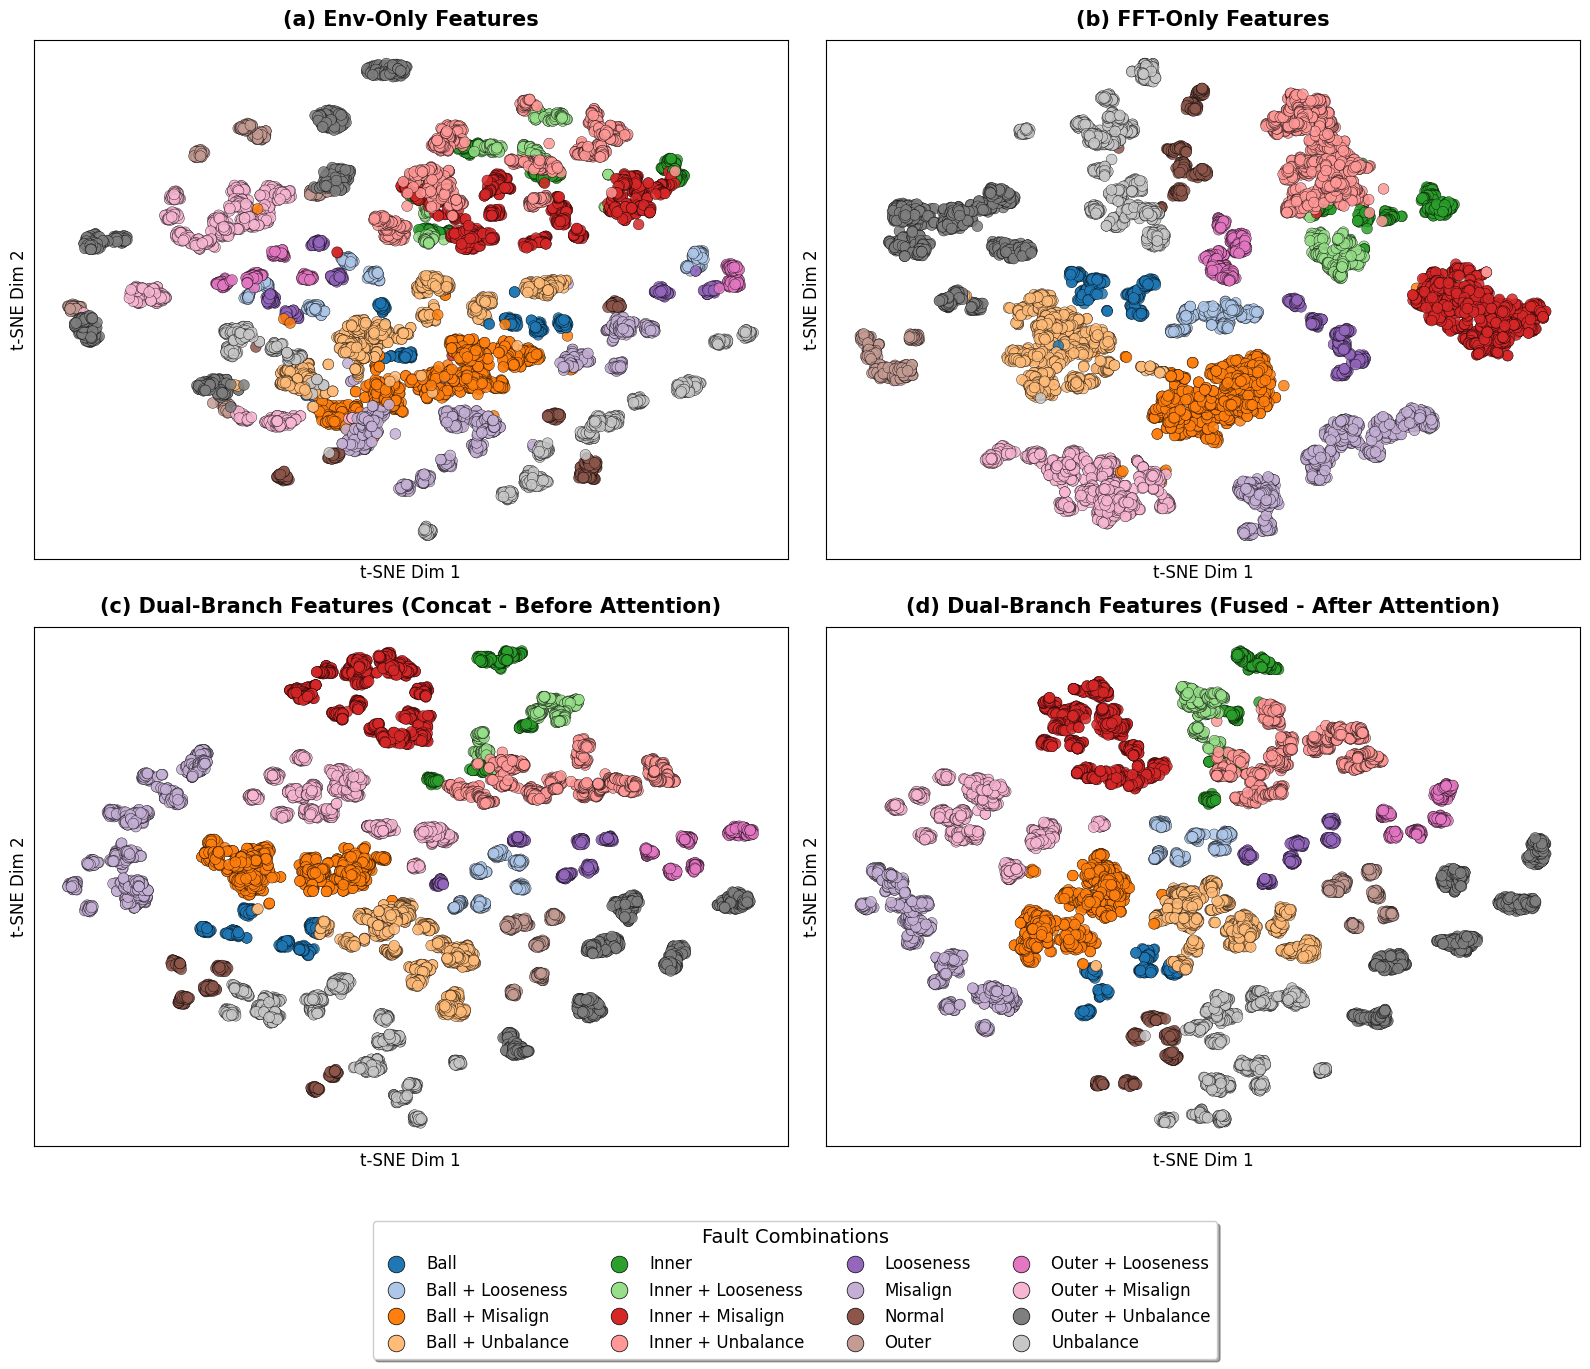

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import torch

def extract_custom_features(model, dataloader, device, hook_point="before_attention"):
    """
    Trích xuất vector đặc trưng tại các vị trí tùy chỉnh:
    - 'before_attention': Ngay sau khi trích xuất đặc trưng nhánh (trước khi tính toán attention).
    - 'after_attention': Ngay sau khi đặc trưng được nhân với trọng số attention (x_weighted).
    """
    model.eval()
    features, labels = [], []
    activation = {}
    
    # Định nghĩa hàm hook để lấy input của layer
    def hook(module, args):
        activation['feat'] = args[0].detach()

    # Đăng ký hook tùy thuộc vào vị trí muốn lấy
    if hook_point == "before_attention":
        # Bắt đầu vào của head (chính là đặc trưng thô từ backbone / hoặc sau khi concat)
        handle = model.head.register_forward_pre_hook(hook)
    elif hook_point == "after_attention":
        # Bắt đầu vào của classifier (chính là x_weighted sau khi qua khối attention)
        handle = model.head.classifier.register_forward_pre_hook(hook)

    with torch.no_grad():
        for env, fft, lbl in dataloader:
            env, fft = env.to(device), fft.to(device)
            _ = model(env, fft)
            features.append(activation['feat'].cpu().numpy())
            labels.append(lbl.cpu().numpy())
            
    handle.remove() # Gỡ hook
    return np.concatenate(features), np.concatenate(labels)

def decode_label(row, target_names):
    """Giải mã one-hot array thành string."""
    active_idx = np.where(row == 1)[0]
    if len(active_idx) == 0: 
        return "Normal"
    return " + ".join([target_names[i] for i in active_idx])

# ---------------------------------------------------------
# 1. TRÍCH XUẤT 4 LOẠI ĐẶC TRƯNG
# ---------------------------------------------------------
print("1. Đang trích xuất đặc trưng...")
# (a) Envelope-Only (Trích xuất nguyên bản - 256 chiều)
feat_env, y_lbl = extract_custom_features(trained_models["Envelope-Only"], test_loader, device, "before_attention")

# (b) FFT-Only (Trích xuất nguyên bản - 256 chiều)
feat_fft, _ = extract_custom_features(trained_models["FFT-Only"], test_loader, device, "before_attention")

# (c) Dual-Branch Trước Attention (Chỉ mới nối lại - 512 chiều)
feat_dual_raw, _ = extract_custom_features(trained_models["Dual-Branch (Ours)"], test_loader, device, "before_attention")

# (d) Dual-Branch Sau Attention (Đã nhân trọng số - 512 chiều)
feat_dual_att, _ = extract_custom_features(trained_models["Dual-Branch (Ours)"], test_loader, device, "after_attention")

y_names = [decode_label(row, TARGET_NAMES) for row in y_lbl]
unique_names, y_class = np.unique(y_names, return_inverse=True)

# ---------------------------------------------------------
# 2. RÚT GỌN CHIỀU VỚI T-SNE
# ---------------------------------------------------------
print("2. Đang chạy t-SNE (Sử dụng PCA giảm xuống 50 chiều trước để tính toán nhanh hơn)...")
# Hàm hỗ trợ chạy PCA -> t-SNE
def compute_tsne(features):
    pca_feat = PCA(n_components=min(50, features.shape[1])).fit_transform(features)
    return TSNE(n_components=2, random_state=42, perplexity=40).fit_transform(pca_feat)

tsne_env      = compute_tsne(feat_env)
tsne_fft      = compute_tsne(feat_fft)
tsne_dual_raw = compute_tsne(feat_dual_raw)
tsne_dual_att = compute_tsne(feat_dual_att)

# ---------------------------------------------------------
# 3. VẼ BIỂU ĐỒ TRỰC QUAN HOÁ (ĐÃ CHỈNH SỬA)
# ---------------------------------------------------------
print("3. Đang vẽ biểu đồ...")
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

titles = [
    "(a) Env-Only Features", 
    "(b) FFT-Only Features", 
    "(c) Dual-Branch Features (Concat - Before Attention)", 
    "(d) Dual-Branch Features (Fused - After Attention)"
]
tsne_results = [tsne_env, tsne_fft, tsne_dual_raw, tsne_dual_att]

# Sử dụng bảng màu tab10 (nếu <=10 lớp) hoặc tab20 (nếu >10 lớp) để có độ tương phản cao nhất
if len(unique_names) <= 10:
    palette = sns.color_palette("tab10", len(unique_names))
else:
    palette = sns.color_palette("tab20", len(unique_names))

for i, (ax, data, title) in enumerate(zip(axes, tsne_results, titles)):
    sns.scatterplot(
        x=data[:, 0], y=data[:, 1],
        hue=y_class,
        palette=palette,
        ax=ax,
        alpha=0.85,          # Tăng độ đậm để màu rực rỡ hơn
        s=60,                # Tăng kích thước điểm
        edgecolor='black',   # Thêm viền đen mỏng để tách biệt các điểm dính nhau
        linewidth=0.3,
        legend=False
    )
    ax.set_title(title, fontsize=15, fontweight='bold', pad=10)
    ax.set_xlabel("t-SNE Dim 1", fontsize=12)
    ax.set_ylabel("t-SNE Dim 2", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

# Chừa ra 15% không gian phía dưới cùng của figure (bottom=0.15) để chứa Legend
plt.tight_layout(rect=[0, 0.15, 1, 1])

# Tạo handles cho legend (có thêm viền đen để đồng bộ với biểu đồ)
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=palette[i], markersize=12, 
                      markeredgecolor='black', markeredgewidth=0.5) 
           for i in range(len(unique_names))]

# Đặt legend ở tọa độ y=0.13 (ngay dưới mép 0.15 của vùng vẽ biểu đồ)
fig.legend(handles, unique_names, title="Fault Combinations", 
           loc="upper center", bbox_to_anchor=(0.5, 0.13), 
           ncol=min(4, len(unique_names)), # Tối đa 4 cột để dàn ngang đẹp hơn
           fontsize=12, title_fontsize=14, frameon=True, shadow=True)

plt.show()

Đang tính toán các chỉ số định lượng (có thể mất vài giây)...

 BẢNG ĐÁNH GIÁ ĐỊNH LƯỢNG CHẤT LƯỢNG KHÔNG GIAN ĐẶC TRƯNG 
                            Model  Silhouette Score (↑)  Calinski-Harabasz (↑)  Davies-Bouldin (↓)
                     (a) Env-Only                0.0688               543.8079              3.1889
                     (b) FFT-Only                0.2712              1448.2758              1.4325
         (c) Dual-Branch (Concat)                0.2076               940.7061              1.7010
(d) Dual-Branch (After Attention)                0.2434              1159.2941              1.4894



C:\Users\Admin\AppData\Local\Temp\ipykernel_9388\719083113.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metrics, x="Model", y="Silhouette Score (↑)", ax=axes[0], palette=colors)
C:\Users\Admin\AppData\Local\Temp\ipykernel_9388\719083113.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metrics, x="Model", y="Calinski-Harabasz (↑)", ax=axes[1], palette=colors)
C:\Users\Admin\AppData\Local\Temp\ipykernel_9388\719083113.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metrics, x="Model", y="Davies-Bouldin 

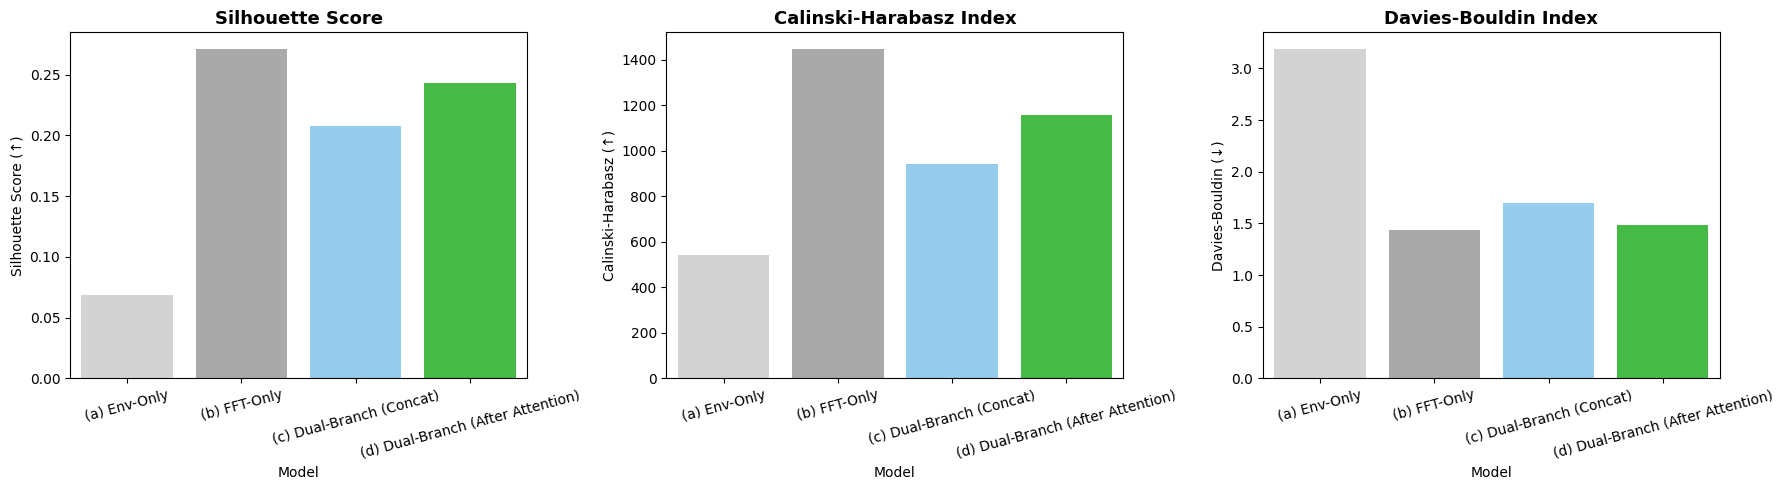

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def calculate_clustering_metrics(X, labels):
    """Tính toán 3 chỉ số đánh giá không gian đặc trưng."""
    if len(np.unique(labels)) < 2:
        return 0, 0, 0
    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)
    return sil, ch, db

# Sử dụng lại chính các vector đặc trưng chưa qua t-SNE đã trích xuất ở cell trước
features_dict = {
    "(a) Env-Only": feat_env,
    "(b) FFT-Only": feat_fft,
    "(c) Dual-Branch (Concat)": feat_dual_raw,
    "(d) Dual-Branch (After Attention)": feat_dual_att
}

# 1. TÍNH TOÁN CÁC CHỈ SỐ
results = []
print("Đang tính toán các chỉ số định lượng (có thể mất vài giây)...")
for name, X in features_dict.items():
    sil, ch, db = calculate_clustering_metrics(X, y_class)
    results.append({
        "Model": name, 
        "Silhouette Score (↑)": sil, 
        "Calinski-Harabasz (↑)": ch, 
        "Davies-Bouldin (↓)": db
    })

df_metrics = pd.DataFrame(results)

# 2. IN BẢNG SO SÁNH
print("\n" + "=" * 80)
print(" BẢNG ĐÁNH GIÁ ĐỊNH LƯỢNG CHẤT LƯỢNG KHÔNG GIAN ĐẶC TRƯNG ")
print("=" * 80)
print(df_metrics.to_string(index=False, float_format="%.4f"))
print("=" * 80 + "\n")

# 3. VẼ BIỂU ĐỒ CỘT SO SÁNH 3 CHỈ SỐ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Palette: dùng màu xanh lá cho (d) để làm nổi bật sự vượt trội
colors = ['#d3d3d3', '#a9a9a9', '#87cefa', '#32cd32'] 

# Vẽ Silhouette
sns.barplot(data=df_metrics, x="Model", y="Silhouette Score (↑)", ax=axes[0], palette=colors)
axes[0].set_title("Silhouette Score", fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Vẽ Calinski-Harabasz
sns.barplot(data=df_metrics, x="Model", y="Calinski-Harabasz (↑)", ax=axes[1], palette=colors)
axes[1].set_title("Calinski-Harabasz Index", fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

# Vẽ Davies-Bouldin (Lưu ý: Cái này càng Thấp càng tốt)
sns.barplot(data=df_metrics, x="Model", y="Davies-Bouldin (↓)", ax=axes[2], palette=colors)
axes[2].set_title("Davies-Bouldin Index", fontsize=13, fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, hamming_loss

# 1. Lấy mô hình Dual-Branch và dự đoán trên tập Test
dual_model = trained_models["Dual-Branch (Ours)"]

# Ở đây đang dùng ngưỡng mặc định là 0.5. Bạn có thể thay đổi nếu muốn.
y_true, y_pred, y_prob = evaluate_model(dual_model, test_loader, device, threshold=0.5)

# 2. Tính toán các chỉ số Tổng thể (Overall Metrics)
global_acc = accuracy_score(y_true, y_pred)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='micro', zero_division=0)
h_loss = hamming_loss(y_true, y_pred)

# 3. Tính toán các chỉ số cho từng Class (Per-Class Metrics)
class_p, class_r, class_f1, class_supp = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)

# 4. In Báo cáo Tổng thể
print("=" * 60)
print(" OVERALL CLASSIFICATION REPORT (Dual-Branch) ".center(60))
print("=" * 60)
print(f"Global Accuracy (Exact Match)  : {global_acc*100:.4f}%")
print(f"Macro Avg (Precision/Recall/F1): {macro_p:.4f} / {macro_r:.4f} / {macro_f1:.4f}")
print(f"Micro Avg (Precision/Recall/F1): {micro_p:.4f} / {micro_r:.4f} / {micro_f1:.4f}")
print(f"Hamming Loss                   : {h_loss:.4f}")

# 5. In Báo cáo Từng Class
print("\n" + "=" * 60)
print(" PER-CLASS METRICS ".center(60))
print("=" * 60)
print(f"{'Class':<15} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'Support':<10}")
print("-" * 60)

for i, name in enumerate(TARGET_NAMES):
    print(f"{name:<15} | {class_p[i]:<10.4f} | {class_r[i]:<10.4f} | {class_f1[i]:<10.4f} | {int(class_supp[i]):<10}")
print("=" * 60)

        OVERALL CLASSIFICATION REPORT (Dual-Branch)         
Global Accuracy (Exact Match)  : 96.6216%
Macro Avg (Precision/Recall/F1): 0.9871 / 0.9875 / 0.9872
Micro Avg (Precision/Recall/F1): 0.9903 / 0.9845 / 0.9874
Hamming Loss                   : 0.0068

                     PER-CLASS METRICS                      
Class           | Precision  | Recall     | F1-Score   | Support   
------------------------------------------------------------
Ball            | 0.9941     | 0.9966     | 0.9954     | 2368      
Inner           | 1.0000     | 0.9975     | 0.9987     | 2368      
Outer           | 0.9996     | 0.9975     | 0.9985     | 2368      
Unbalance       | 0.9813     | 0.9474     | 0.9640     | 3552      
Misalign        | 0.9977     | 0.9935     | 0.9956     | 3552      
Looseness       | 0.9499     | 0.9924     | 0.9707     | 1184      


In [14]:
import numpy as np
from collections import Counter
from sklearn.metrics import precision_recall_fscore_support

# 1. Chuyển đổi vector thành chuỗi tổ hợp lỗi
y_true_str = np.array([decode_label(row, TARGET_NAMES) for row in y_true])
y_pred_str = np.array([decode_label(row, TARGET_NAMES) for row in y_pred])

# 2. Tìm danh sách các tổ hợp THỰC SỰ TỒN TẠI trong tập Test
true_counts = Counter(y_true_str)
valid_classes = sorted([cls for cls, count in true_counts.items() if count > 0])

# 3. Tính toán Metric thủ công cho các lớp hợp lệ
print("=" * 70)
print(" CLEAN COMPOUND FAULT REPORT (Valid Combinations Only) ".center(70))
print("=" * 70)
print(f"{'Compound Fault':<25} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'Support':<10}")
print("-" * 70)

macro_p, macro_r, macro_f1 = 0, 0, 0

for cls in valid_classes:
    # Coi lớp hiện tại là Positive (1), tất cả còn lại là Negative (0)
    y_true_bin = (y_true_str == cls).astype(int)
    y_pred_bin = (y_pred_str == cls).astype(int)
    
    p, r, f1, _ = precision_recall_fscore_support(y_true_bin, y_pred_bin, average='binary', zero_division=0)
    
    macro_p += p
    macro_r += r
    macro_f1 += f1
    
    print(f"{cls:<25} | {p:<10.4f} | {r:<10.4f} | {f1:<10.4f} | {true_counts[cls]:<10}")

# 4. In thông số tổng kết (Đã loại bỏ nhiễu)
num_valid = len(valid_classes)
print("-" * 70)
print(f"{'Macro Avg (Valid Classes)':<25} | {macro_p/num_valid:<10.4f} | {macro_r/num_valid:<10.4f} | {macro_f1/num_valid:<10.4f} | {len(y_true_str):<10}")
print("=" * 70)

        CLEAN COMPOUND FAULT REPORT (Valid Combinations Only)         
Compound Fault            | Precision  | Recall     | F1-Score   | Support   
----------------------------------------------------------------------
Ball                      | 0.8701     | 0.9730     | 0.9187     | 296       
Ball + Looseness          | 0.9794     | 0.9628     | 0.9710     | 296       
Ball + Misalign           | 0.9932     | 0.9854     | 0.9893     | 888       
Ball + Unbalance          | 0.9814     | 0.9516     | 0.9663     | 888       
Inner                     | 0.8383     | 0.8581     | 0.8481     | 296       
Inner + Looseness         | 0.8276     | 0.9730     | 0.8944     | 296       
Inner + Misalign          | 0.9977     | 0.9921     | 0.9949     | 888       
Inner + Unbalance         | 0.9637     | 0.8975     | 0.9294     | 888       
Looseness                 | 0.9966     | 0.9764     | 0.9863     | 296       
Misalign                  | 0.9921     | 0.9932     | 0.9927     | 888       
